TASK 1: KNN Classification on Iris Dataset

Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Class Distribution: [50 50 50]

--- Data Preprocessing ---
Training set size: 120 samples
Test set size: 30 samples
Features scaled to zero mean and unit variance

--- Model Training ---

Best K value: 1
Best test accuracy: 0.9667

--- Distance Metrics Comparison ---

EUCLIDEAN Distance (K=1):
  Accuracy: 0.9667
  Weighted F1-Score: 0.9666

MANHATTAN Distance (K=1):
  Accuracy: 0.9667
  Weighted F1-Score: 0.9666

--- Final Model Evaluation ---

Classification Report (K=1, Euclidean):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97

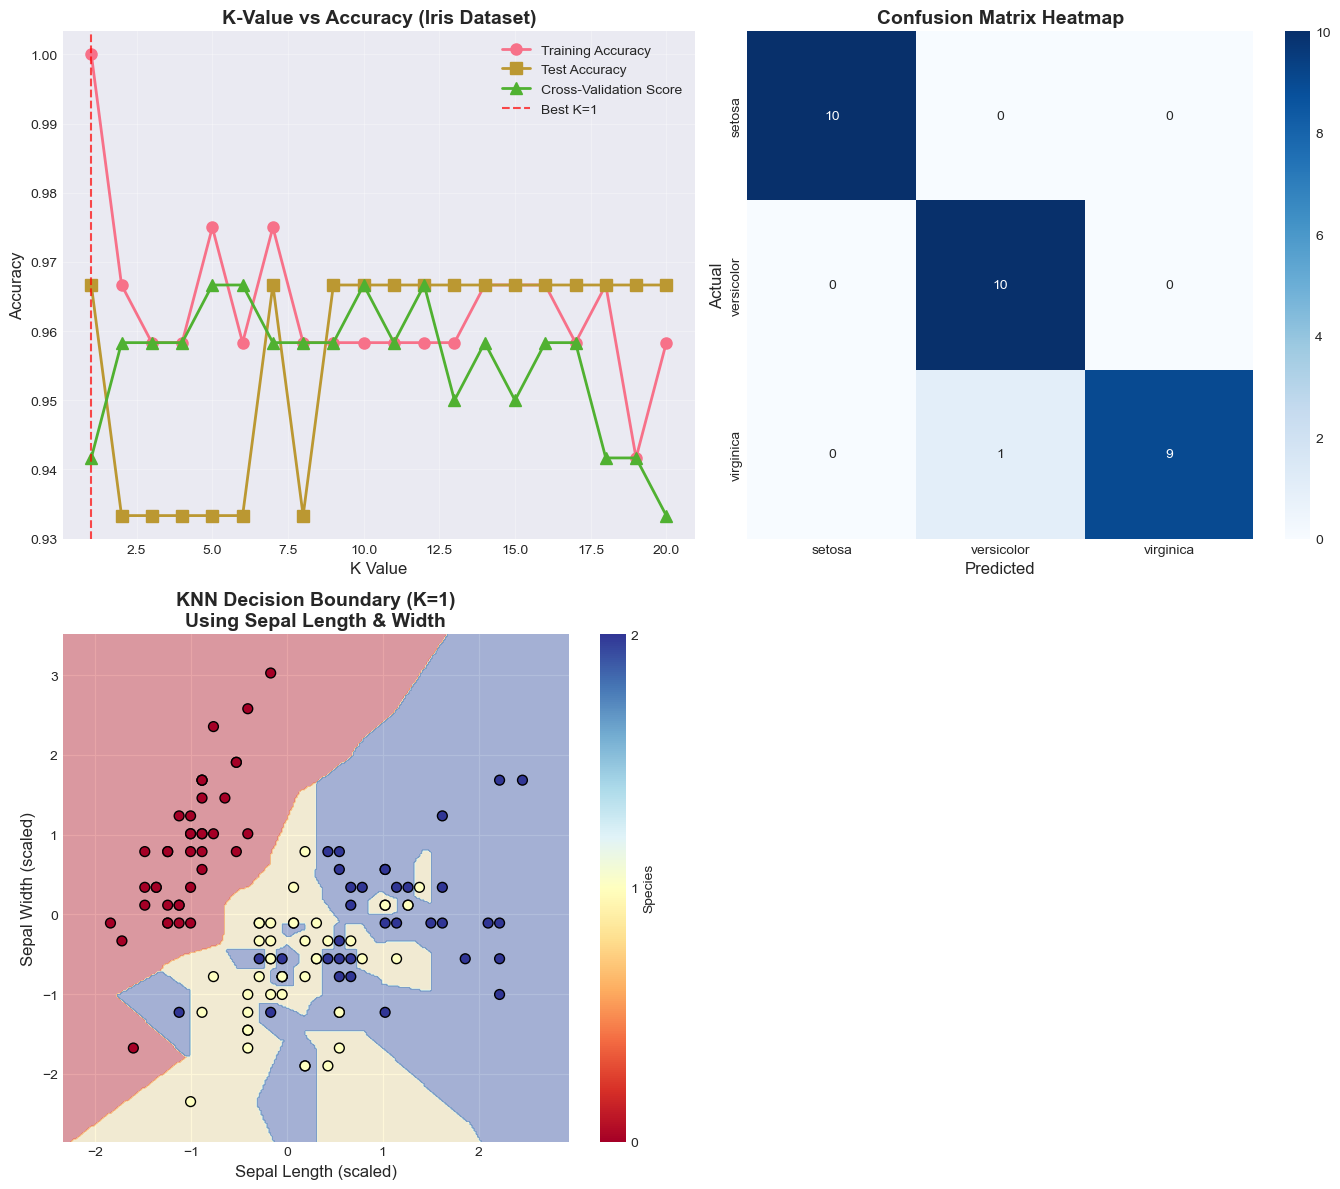

<Figure size 1200x1000 with 0 Axes>

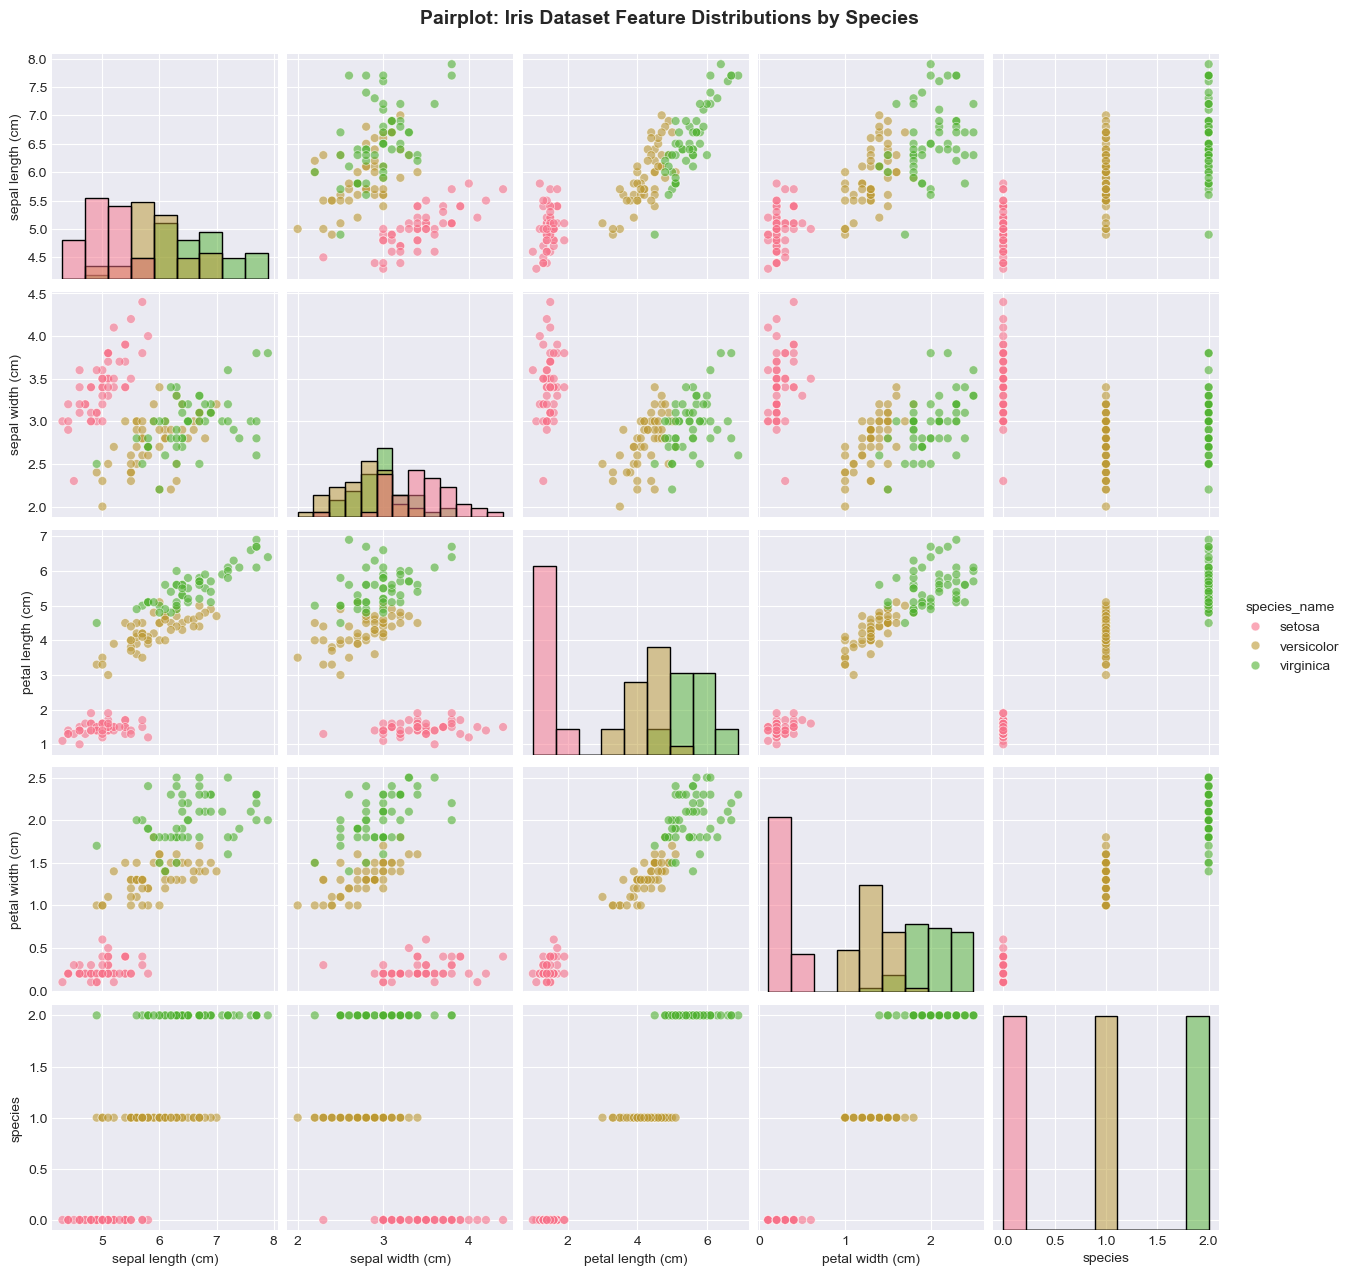


Task 1 Complete!


In [1]:
# ============================================
# TASK 1: KNN Classification on Iris Dataset
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. Load and Explore Dataset
# ============================================
print("="*60)
print("TASK 1: KNN Classification on Iris Dataset")
print("="*60)

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"\nDataset Shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {target_names}")
print(f"Class Distribution: {np.bincount(y)}")

# Create DataFrame for visualization
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = y
df_iris['species_name'] = df_iris['species'].map({i: name for i, name in enumerate(target_names)})

# ============================================
# 2. Data Preprocessing - Normalization
# ============================================
print("\n--- Data Preprocessing ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# StandardScaler for feature normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Test set size: {X_test_scaled.shape[0]} samples")
print(f"Features scaled to zero mean and unit variance")

# ============================================
# 3. Model Training with Different K Values
# ============================================
print("\n--- Model Training ---")

k_values = range(1, 21)
train_accuracies = []
test_accuracies = []
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    
    # Training accuracy
    train_pred = knn.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_acc)
    
    # Testing accuracy
    test_pred = knn.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_acc)
    
    # Cross-validation score
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()
    cv_scores.append(cv_score)

# Find best K
best_k = k_values[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)
print(f"\nBest K value: {best_k}")
print(f"Best test accuracy: {best_accuracy:.4f}")

# ============================================
# 4. Distance Metrics Exploration (Euclidean vs Manhattan)
# ============================================
print("\n--- Distance Metrics Comparison ---")

metrics = ['euclidean', 'manhattan']
metric_results = {}

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    metric_results[metric] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }
    print(f"\n{metric.upper()} Distance (K={best_k}):")
    print(f"  Accuracy: {metric_results[metric]['accuracy']:.4f}")
    print(f"  Weighted F1-Score: {metric_results[metric]['f1']:.4f}")

# Train final model with best K and Euclidean distance
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
final_knn.fit(X_train_scaled, y_train)
y_pred_final = final_knn.predict(X_test_scaled)
y_pred_proba = final_knn.predict_proba(X_test_scaled)

# ============================================
# 5. Evaluation Metrics
# ============================================
print("\n--- Final Model Evaluation ---")
print(f"\nClassification Report (K={best_k}, Euclidean):")
print(classification_report(y_test, y_pred_final, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

# ============================================
# 6. Visualizations
# ============================================

# FIGURE 1: K vs Accuracy Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax1 = axes[0, 0]
ax1.plot(k_values, train_accuracies, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
ax1.plot(k_values, test_accuracies, 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax1.plot(k_values, cv_scores, '^-', label='Cross-Validation Score', linewidth=2, markersize=8)
ax1.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
ax1.set_xlabel('K Value', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('K-Value vs Accuracy (Iris Dataset)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# FIGURE 2: Confusion Matrix Heatmap
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, ax=ax2)
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')

# FIGURE 3: Decision Boundary Visualization (using first two features)
ax3 = axes[1, 0]
# Create mesh grid for first two features only
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Train KNN on first two features for visualization
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_scaled[:, :2], y_train)

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax3.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
scatter = ax3.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], 
                      c=y_train, cmap='RdYlBu', edgecolors='black', s=50)
ax3.set_xlabel('Sepal Length (scaled)', fontsize=12)
ax3.set_ylabel('Sepal Width (scaled)', fontsize=12)
ax3.set_title(f'KNN Decision Boundary (K={best_k})\nUsing Sepal Length & Width', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax3, ticks=[0, 1, 2], label='Species')

# FIGURE 4: Data Distribution Pairplot
ax4 = axes[1, 1]
ax4.remove()  # Remove the subplot as we'll use a separate figure for pairplot

plt.tight_layout()
plt.show()

# Separate pairplot for better visualization
fig2 = plt.figure(figsize=(12, 10))
sns.pairplot(df_iris, hue='species_name', diag_kind='hist', 
             plot_kws={'alpha': 0.6, 's': 40})
plt.suptitle('Pairplot: Iris Dataset Feature Distributions by Species', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("\n" + "="*60)
print("Task 1 Complete!")
print("="*60)


TASK 2: Decision Tree Classification

Dataset Shape: (569, 30)
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Classes: ['malignant' 'benign']
Class Distribution (Benign=0, Malignant=1): [212 357]

--- Gini vs Entropy Comparison ---

GINI Criterion:
  Accuracy: 0.9123
  F1-Score: 0.9286
  ROC-AUC: 0.9157

ENTROPY Criterion:
  Accuracy: 0.9123
  F1-Score: 0.9275
  ROC-AUC: 0.9206

--- Hyperparameter Tuning ---

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_sample

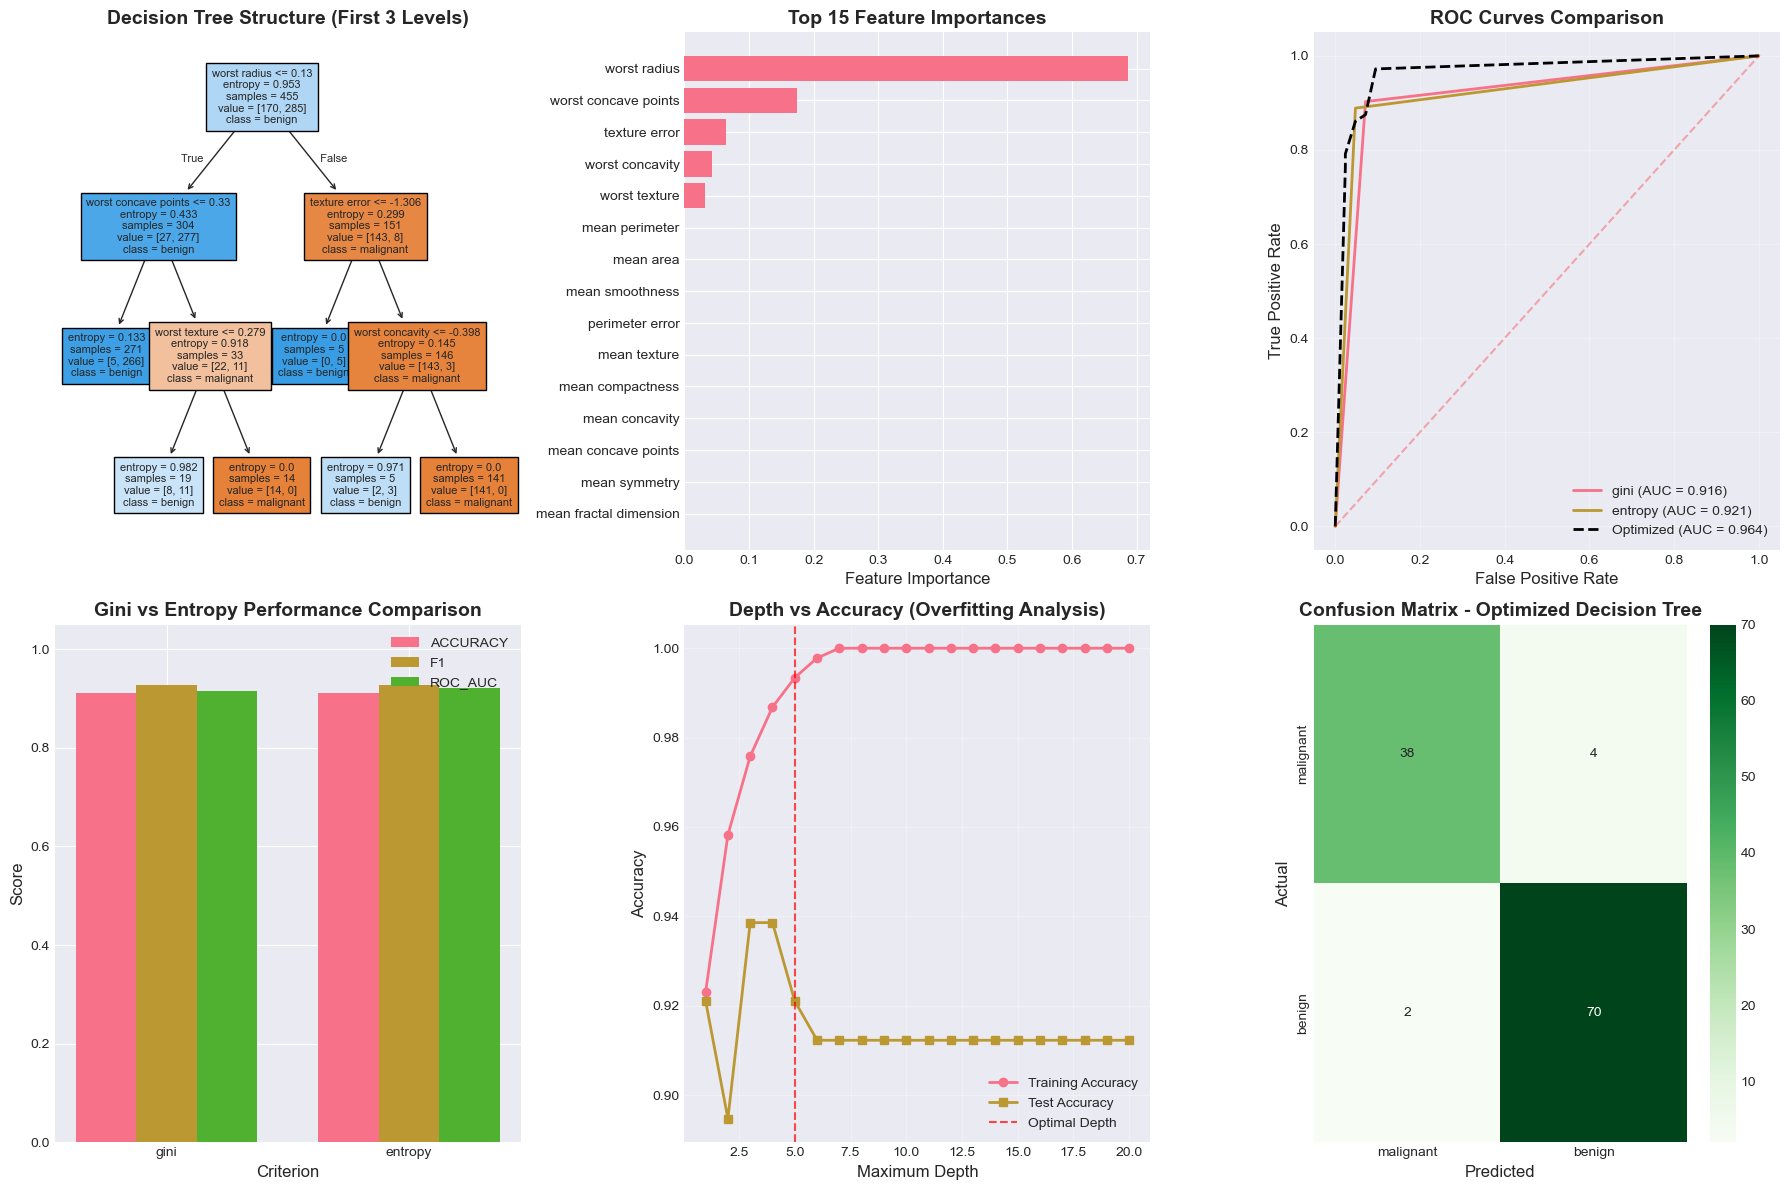


Task 2 Complete!


In [2]:
# ============================================
# TASK 2: Decision Tree on Breast Cancer Dataset
# ============================================

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. Load Dataset
# ============================================
print("\n" + "="*60)
print("TASK 2: Decision Tree Classification")
print("="*60)

cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

print(f"\nDataset Shape: {X_cancer.shape}")
print(f"Features: {cancer.feature_names}")
print(f"Classes: {cancer.target_names}")
print(f"Class Distribution (Benign=0, Malignant=1): {np.bincount(y_cancer)}")

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, stratify=y_cancer, random_state=42
)

# Feature scaling (optional but recommended)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# ============================================
# 2. Model Construction - Gini vs Entropy
# ============================================
print("\n--- Gini vs Entropy Comparison ---")

criterion_results = {}
criterion_models = {}

for criterion in ['gini', 'entropy']:
    dt = DecisionTreeClassifier(criterion=criterion, random_state=42)
    dt.fit(X_train_c_scaled, y_train_c)
    y_pred = dt.predict(X_test_c_scaled)
    
    y_pred_proba = dt.predict_proba(X_test_c_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    criterion_results[criterion] = {
        'accuracy': accuracy_score(y_test_c, y_pred),
        'precision': precision_score(y_test_c, y_pred),
        'recall': recall_score(y_test_c, y_pred),
        'f1': f1_score(y_test_c, y_pred),
        'roc_auc': roc_auc
    }
    criterion_models[criterion] = dt
    
    print(f"\n{criterion.upper()} Criterion:")
    print(f"  Accuracy: {criterion_results[criterion]['accuracy']:.4f}")
    print(f"  F1-Score: {criterion_results[criterion]['f1']:.4f}")
    print(f"  ROC-AUC: {criterion_results[criterion]['roc_auc']:.4f}")

# ============================================
# 3. Hyperparameter Tuning
# ============================================
print("\n--- Hyperparameter Tuning ---")

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train_c_scaled, y_train_c)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Train optimized model
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test_c_scaled)
y_pred_proba_best = best_dt.predict_proba(X_test_c_scaled)[:, 1]

# ============================================
# 4. Cost Complexity Pruning
# ============================================
print("\n--- Cost Complexity Pruning ---")

path = best_dt.cost_complexity_pruning_path(X_train_c_scaled, y_train_c)
ccp_alphas = path.ccp_alphas[:-1]  # Exclude last alpha

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=42)
    dt_pruned.fit(X_train_c_scaled, y_train_c)
    train_scores.append(dt_pruned.score(X_train_c_scaled, y_train_c))
    test_scores.append(dt_pruned.score(X_test_c_scaled, y_test_c))

optimal_alpha_idx = np.argmax(test_scores)
optimal_alpha = ccp_alphas[optimal_alpha_idx]
print(f"Optimal ccp_alpha: {optimal_alpha:.6f}")

# Final pruned model
final_dt = DecisionTreeClassifier(criterion='entropy', ccp_alpha=optimal_alpha, 
                                   random_state=42, **grid_search.best_params_)
final_dt.fit(X_train_c_scaled, y_train_c)
y_pred_final_dt = final_dt.predict(X_test_c_scaled)

print(f"\nFinal Model Accuracy: {accuracy_score(y_test_c, y_pred_final_dt):.4f}")
print(classification_report(y_test_c, y_pred_final_dt, target_names=cancer.target_names))

# ============================================
# 5. Visualizations
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# FIGURE 1: Decision Tree Structure
ax1 = axes[0, 0]
plot_tree(final_dt, max_depth=3, feature_names=cancer.feature_names,
          class_names=cancer.target_names, filled=True, ax=ax1, fontsize=8)
ax1.set_title('Decision Tree Structure (First 3 Levels)', fontsize=14, fontweight='bold')

# FIGURE 2: Feature Importance Plot
ax2 = axes[0, 1]
importances = final_dt.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features

ax2.barh(range(len(indices)), importances[indices])
ax2.set_yticks(range(len(indices)))
ax2.set_yticklabels([cancer.feature_names[i] for i in indices])
ax2.set_xlabel('Feature Importance', fontsize=12)
ax2.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')

# FIGURE 3: ROC Curve
ax3 = axes[0, 2]
for criterion in ['gini', 'entropy']:
    y_proba = criterion_models[criterion].predict_proba(X_test_c_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, y_proba)
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, label=f'{criterion} (AUC = {roc_auc:.3f})', linewidth=2)

# Add final model ROC
fpr_final, tpr_final, _ = roc_curve(y_test_c, y_pred_proba_best)
roc_auc_final = auc(fpr_final, tpr_final)
ax3.plot(fpr_final, tpr_final, 'k--', label=f'Optimized (AUC = {roc_auc_final:.3f})', linewidth=2)

ax3.plot([0, 1], [0, 1], 'r--', alpha=0.3)
ax3.set_xlabel('False Positive Rate', fontsize=12)
ax3.set_ylabel('True Positive Rate', fontsize=12)
ax3.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# FIGURE 4: Impurity Comparison Plot
ax4 = axes[1, 0]
criteria_names = list(criterion_results.keys())
metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
x = np.arange(len(criteria_names))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [criterion_results[c][metric] for c in criteria_names]
    ax4.bar(x + i*width, values, width, label=metric.upper())

ax4.set_xlabel('Criterion', fontsize=12)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Gini vs Entropy Performance Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x + width)
ax4.set_xticklabels(criteria_names)
ax4.legend()
ax4.set_ylim([0, 1.05])

# FIGURE 5: Depth vs Accuracy Curve
ax5 = axes[1, 1]
depth_values = range(1, 21)
train_depths = []
test_depths = []

for depth in depth_values:
    dt_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_depth.fit(X_train_c_scaled, y_train_c)
    train_depths.append(dt_depth.score(X_train_c_scaled, y_train_c))
    test_depths.append(dt_depth.score(X_test_c_scaled, y_test_c))

ax5.plot(depth_values, train_depths, 'o-', label='Training Accuracy', linewidth=2, markersize=6)
ax5.plot(depth_values, test_depths, 's-', label='Test Accuracy', linewidth=2, markersize=6)
ax5.axvline(x=grid_search.best_params_.get('max_depth', 5) if grid_search.best_params_.get('max_depth') else 20, 
            color='red', linestyle='--', alpha=0.7, label='Optimal Depth')
ax5.set_xlabel('Maximum Depth', fontsize=12)
ax5.set_ylabel('Accuracy', fontsize=12)
ax5.set_title('Depth vs Accuracy (Overfitting Analysis)', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# FIGURE 6: Confusion Matrix for Final Model
ax6 = axes[1, 2]
cm_final = confusion_matrix(y_test_c, y_pred_final_dt)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=ax6)
ax6.set_xlabel('Predicted', fontsize=12)
ax6.set_ylabel('Actual', fontsize=12)
ax6.set_title('Confusion Matrix - Optimized Decision Tree', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Task 2 Complete!")
print("="*60)


TASK 3: Handwritten Digit Recognition with KNN

Dataset Shape: (1797, 8, 8)
Images: 1797 samples of 8×8 = 64 pixels
Classes: [0 1 2 3 4 5 6 7 8 9]
Class Distribution: [178 182 177 183 181 182 181 179 174 180]

--- Data Preprocessing ---
Flattened shape: (1797, 64)

--- Finding Optimal K Value ---
Optimal K value: 1

--- Training Final Model ---

Final Model Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      0.97      0.97        35
           3       0.97      1.00      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.94      0.89      0.91        35
           9       1.00      0.92      0.96        36

  

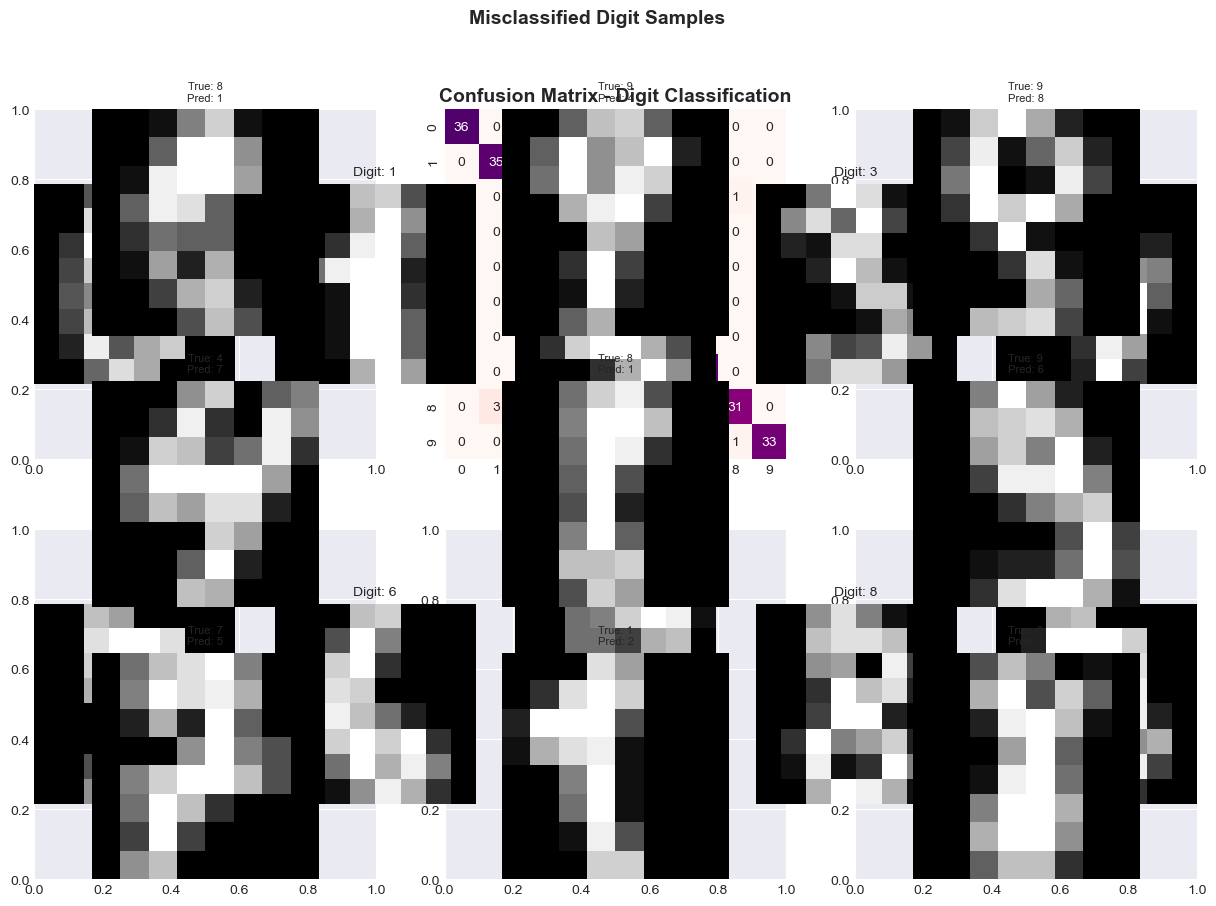

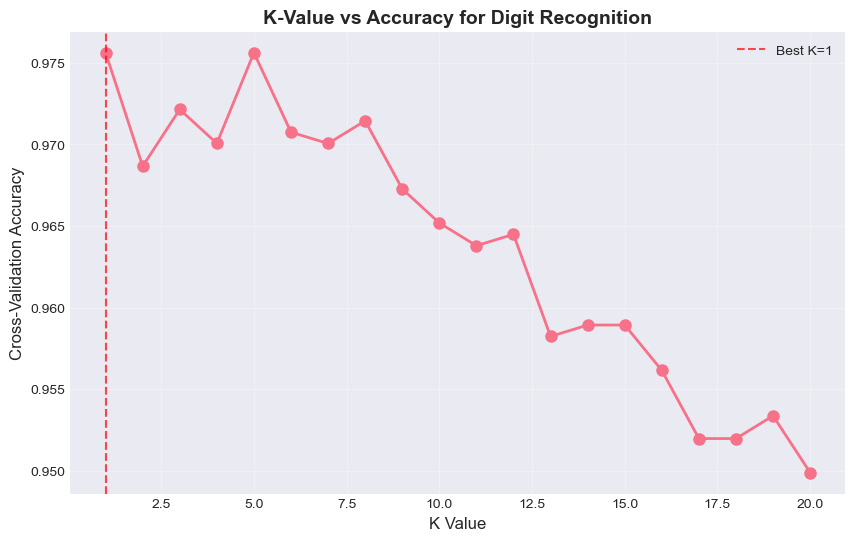


Task 3 Complete!


In [3]:
# ============================================
# TASK 3: Image Classification using KNN
# ============================================

from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ============================================
# 1. Load Dataset
# ============================================
print("\n" + "="*60)
print("TASK 3: Handwritten Digit Recognition with KNN")
print("="*60)

digits = load_digits()
X_digits = digits.images
y_digits = digits.target

print(f"\nDataset Shape: {X_digits.shape}")
print(f"Images: {X_digits.shape[0]} samples of 8×8 = {X_digits.shape[1]*X_digits.shape[2]} pixels")
print(f"Classes: {digits.target_names}")
print(f"Class Distribution: {np.bincount(y_digits)}")

# ============================================
# 2. Flatten and Preprocess
# ============================================
print("\n--- Data Preprocessing ---")

# Flatten images
n_samples = len(X_digits)
X_digits_flat = X_digits.reshape(n_samples, -1)
print(f"Flattened shape: {X_digits_flat.shape}")

# Train-test split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits_flat, y_digits, test_size=0.2, stratify=y_digits, random_state=42
)

# Standardize features
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

# ============================================
# 3. Find Optimal K
# ============================================
print("\n--- Finding Optimal K Value ---")

k_values_d = range(1, 21)
cv_scores_d = []

for k in k_values_d:
    knn_d = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn_d, X_train_d_scaled, y_train_d, cv=5)
    cv_scores_d.append(scores.mean())

best_k_d = k_values_d[np.argmax(cv_scores_d)]
print(f"Optimal K value: {best_k_d}")

# ============================================
# 4. Train Final Model
# ============================================
print("\n--- Training Final Model ---")

final_knn_digits = KNeighborsClassifier(n_neighbors=best_k_d, metric='euclidean')
final_knn_digits.fit(X_train_d_scaled, y_train_d)
y_pred_d = final_knn_digits.predict(X_test_d_scaled)

accuracy_d = accuracy_score(y_test_d, y_pred_d)
print(f"\nFinal Model Accuracy: {accuracy_d:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_d))

# ============================================
# 5. Visualizations
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# FIGURE 1: Sample Digit Images
ax1 = axes[0, 0]
for i in range(10):
    ax1.imshow(digits.images[i], cmap='gray')
    ax1.set_title(f'Label: {digits.target[i]}')
    ax1.axis('off')
ax1.set_title('Sample Digit Images', fontsize=14, fontweight='bold')

# Better sample display
ax1_sub = axes[0, 0]
ax1_sub.remove()
ax1_sub = plt.subplot(2, 3, 1)

# Create a grid of sample images
sample_images = []
sample_labels = []
for digit in range(10):
    idx = np.where(y_digits == digit)[0][0]
    sample_images.append(X_digits[idx])
    sample_labels.append(digit)

for i, (img, label) in enumerate(zip(sample_images, sample_labels)):
    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Digit: {label}', fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Digit Images from Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()

# FIGURE 2: Confusion Matrix Heatmap
ax2 = plt.subplot(2, 3, 2)
cm_digits = confusion_matrix(y_test_d, y_pred_d)
sns.heatmap(cm_digits, annot=True, fmt='d', cmap='RdPu', ax=ax2, cbar=False)
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_title('Confusion Matrix - Digit Classification', fontsize=14, fontweight='bold')

# FIGURE 3: Misclassified Samples Visualization
ax3 = plt.subplot(2, 3, 3)
misclassified_idx = np.where(y_test_d != y_pred_d)[0]
print(f"\nNumber of misclassified samples: {len(misclassified_idx)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(y_test_d)*100:.2f}%")

# Display first 9 misclassified samples
for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test_d[idx].reshape(8, 8), cmap='gray')
    plt.title(f'True: {y_test_d[idx]}\nPred: {y_pred_d[idx]}', fontsize=8)
    plt.axis('off')
plt.suptitle('Misclassified Digit Samples', fontsize=14, fontweight='bold')
plt.tight_layout()

# Additional: K vs Accuracy Plot
plt.figure(figsize=(10, 6))
plt.plot(k_values_d, cv_scores_d, 'o-', linewidth=2, markersize=8)
plt.axvline(x=best_k_d, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_d}')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('K-Value vs Accuracy for Digit Recognition', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*60)
print("Task 3 Complete!")
print("="*60)


TASK 4: KNN with KD-Tree Optimization (Wine Dataset)

Dataset Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']
Class Distribution: [59 71 48]

Training samples: 142
Test samples: 36

--- Finding Optimal K ---
Optimal K value: 18

--- KD-Tree vs Brute Force Comparison ---

KD_TREE Algorithm:
  Accuracy: 0.9722
  F1-Score: 0.9723
  Fit Time: 0.0000 ms
  Predict Time: 0.0000 ms

BRUTE Algorithm:
  Accuracy: 0.9722
  F1-Score: 0.9723
  Fit Time: 0.0000 ms
  Predict Time: 0.0000 ms


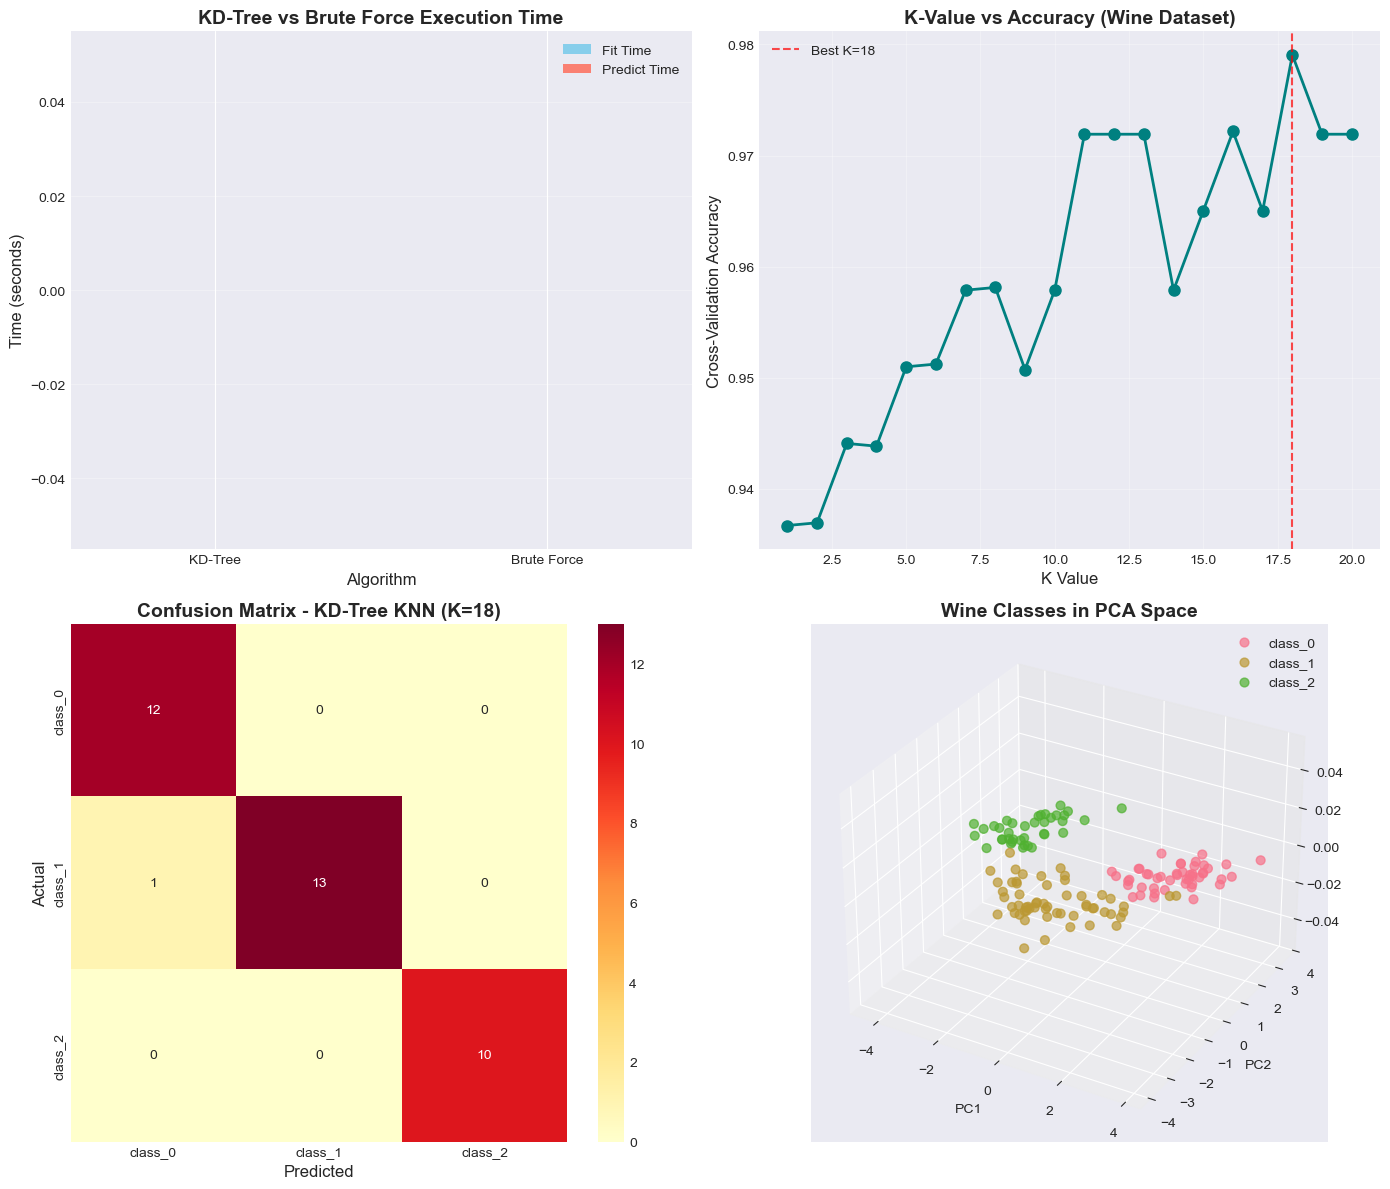

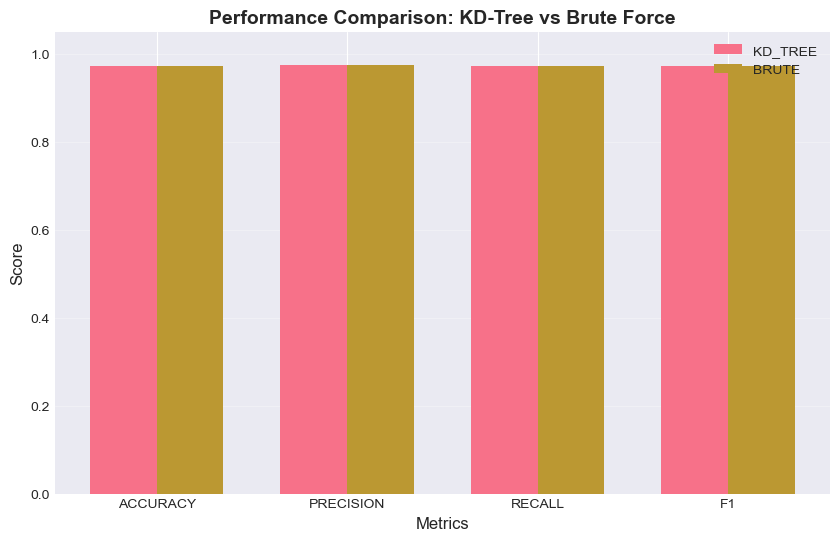


Task 4 Complete!


In [4]:
# ============================================
# TASK 4: KNN with KD-Tree Optimization
# ============================================

from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

# ============================================
# 1. Load Dataset
# ============================================
print("\n" + "="*60)
print("TASK 4: KNN with KD-Tree Optimization (Wine Dataset)")
print("="*60)

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(f"\nDataset Shape: {X_wine.shape}")
print(f"Features: {wine.feature_names}")
print(f"Classes: {wine.target_names}")
print(f"Class Distribution: {np.bincount(y_wine)}")

# ============================================
# 2. Data Preprocessing
# ============================================
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=42
)

scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

print(f"\nTraining samples: {len(X_train_w_scaled)}")
print(f"Test samples: {len(X_test_w_scaled)}")

# ============================================
# 3. Find Optimal K
# ============================================
print("\n--- Finding Optimal K ---")

k_values_w = range(1, 21)
knn_scores = []
knn_models_kdtree = {}

for k in k_values_w:
    knn_kdtree = KNeighborsClassifier(n_neighbors=k, algorithm='kd_tree')
    scores = cross_val_score(knn_kdtree, X_train_w_scaled, y_train_w, cv=5)
    knn_scores.append(scores.mean())

best_k_w = k_values_w[np.argmax(knn_scores)]
print(f"Optimal K value: {best_k_w}")

# ============================================
# 4. Compare KD-Tree vs Brute Force
# ============================================
print("\n--- KD-Tree vs Brute Force Comparison ---")

algorithms = ['kd_tree', 'brute']
algorithm_results = []
algorithm_times = {'fit': [], 'predict': []}

for algo in algorithms:
    # Measure fit time
    start_fit = time.time()
    knn = KNeighborsClassifier(n_neighbors=best_k_w, algorithm=algo)
    knn.fit(X_train_w_scaled, y_train_w)
    fit_time = time.time() - start_fit
    
    # Measure predict time
    start_pred = time.time()
    y_pred = knn.predict(X_test_w_scaled)
    pred_time = time.time() - start_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_w, y_pred)
    precision = precision_score(y_test_w, y_pred, average='weighted')
    recall = recall_score(y_test_w, y_pred, average='weighted')
    f1 = f1_score(y_test_w, y_pred, average='weighted')
    
    algorithm_results.append({
        'algorithm': algo.upper(),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fit_time': fit_time,
        'predict_time': pred_time,
        'total_time': fit_time + pred_time
    })
    
    algorithm_times['fit'].append(fit_time)
    algorithm_times['predict'].append(pred_time)
    
    print(f"\n{algo.upper()} Algorithm:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Fit Time: {fit_time*1000:.4f} ms")
    print(f"  Predict Time: {pred_time*1000:.4f} ms")

# ============================================
# 5. Class Separation Analysis (PCA for visualization)
# ============================================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_w_scaled)
X_test_pca = pca.transform(X_test_w_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=best_k_w, algorithm='kd_tree')
knn_pca.fit(X_train_pca, y_train_w)

# ============================================
# 6. Visualizations
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# FIGURE 1: KD-Tree vs Brute Force Execution Time
ax1 = axes[0, 0]
x_pos = np.arange(len(algorithms))
width = 0.35

ax1.bar(x_pos - width/2, algorithm_times['fit'], width, label='Fit Time', color='skyblue')
ax1.bar(x_pos + width/2, algorithm_times['predict'], width, label='Predict Time', color='salmon')
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_xlabel('Algorithm', fontsize=12)
ax1.set_title('KD-Tree vs Brute Force Execution Time', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['KD-Tree', 'Brute Force'])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# FIGURE 2: K vs Accuracy Curve
ax2 = axes[0, 1]
ax2.plot(k_values_w, knn_scores, 'o-', linewidth=2, markersize=8, color='teal')
ax2.axvline(x=best_k_w, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_w}')
ax2.set_xlabel('K Value', fontsize=12)
ax2.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax2.set_title('K-Value vs Accuracy (Wine Dataset)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# FIGURE 3: Confusion Matrix Heatmap
ax3 = axes[1, 0]
# Train final KD-Tree model
final_knn_w = KNeighborsClassifier(n_neighbors=best_k_w, algorithm='kd_tree')
final_knn_w.fit(X_train_w_scaled, y_train_w)
y_pred_w = final_knn_w.predict(X_test_w_scaled)
cm_w = confusion_matrix(y_test_w, y_pred_w)

sns.heatmap(cm_w, annot=True, fmt='d', cmap='YlOrRd', ax=ax3,
            xticklabels=wine.target_names, yticklabels=wine.target_names)
ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('Actual', fontsize=12)
ax3.set_title(f'Confusion Matrix - KD-Tree KNN (K={best_k_w})', fontsize=14, fontweight='bold')

# FIGURE 4: Pairwise Feature Distribution (first 4 features)
ax4 = axes[1, 1]
from mpl_toolkits.mplot3d import Axes3D
ax4.remove()
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

# Plot first three PCA components for 3D visualization
for i, target_name in enumerate(wine.target_names):
    indices = y_train_w == i
    ax4.scatter(X_train_pca[indices, 0], X_train_pca[indices, 1], 
                np.zeros_like(X_train_pca[indices, 0]),
                label=target_name, alpha=0.7, s=40)
ax4.set_xlabel('PC1', fontsize=10)
ax4.set_ylabel('PC2', fontsize=10)
ax4.set_title('Wine Classes in PCA Space', fontsize=14, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

# Additional performance comparison bar plot
fig2, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.35

for i, result in enumerate(algorithm_results):
    values = [result[m] for m in metrics_to_plot]
    ax.bar(x + i*width, values, width, label=result['algorithm'])

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metrics', fontsize=12)
ax.set_title('Performance Comparison: KD-Tree vs Brute Force', fontsize=14, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')
plt.show()

print("\n" + "="*60)
print("Task 4 Complete!")
print("="*60)